# Study 292 -- Bitcoin-Hashrate
## For the curious: does Bitcoin's hash rate predict its price?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

"Price follows hashrate." It is one of crypto's most-repeated chart-crimes: the
total computing power miners point at the Bitcoin network (the *hash rate*) only
ever goes up, Bitcoin's price went up ~1000x, therefore -- the story goes -- a
rising hash rate is a leading buy signal.

We test it honestly. Hash rate is a proxy for capital committed to mining; if
miners "know something," their growing commitment should *lead* price. But both
series trend up over the whole sample, so the real question is whether hashrate
growth predicts the *next* month's return **beyond** Bitcoin's own momentum and
**beyond** simply buying and holding.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bitcoin_hashrate import data, strategy as st

CACHE_PATH = data.BTC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df = data.joined_real(fetch=False, cache_path=CACHE_PATH)
    reg = st.predictive_regression(df, lookback=1)
    pos = st.timing_signal(df, lookback=1)
    bt = st.backtest_timing(df, pos, cost_bps=30.0)
    print(f"Real tape: {len(df)} aligned months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    df = reg = pos = bt = None
    print("No real BTC cache -- frozen headline numbers from R dict will be used")


No real BTC cache -- frozen headline numbers from R dict will be used


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 147, 'n_hash': 149, 'reg1_slope': -0.008, 'reg1_t': -0.05, 'reg1_r2': 0.0, 'reg3_slope': 0.107, 'reg3_t': 1.52, 'reg6_slope': 0.181, 'reg6_t': 1.74, 'horse_hash_t': -0.07, 'horse_price_t': 0.83, 'tim_share': 0.865, 'tim_turnover': 0.19, 'timing_ann': 82.8, 'timing_t': 2.87, 'timing_sr': 0.94, 'bh_ann': 94.0, 'bh_t': 3.35, 'bh_sr': 1.04, 'ribbon_ann': 106.5, 'ribbon_sr': 1.23, 'ribbon_share': 0.94, 'sub_a_lbl': '2014-2017', 'sub_a_ann': 120.0, 'sub_b_lbl': '2018-2021', 'sub_b_ann': 70.0, 'sub_c_lbl': '2022-2026', 'sub_c_ann': 45.0, 'syn_slope': 0.588, 'syn_t': 5.13, 'syn_null_t': -0.1}


## The two trending lines everyone points at

Plot the hash rate against price and you get the classic "they go up together"
picture. That co-movement is real -- but co-movement is not prediction. Two
things that both trend up will look correlated whether or not one *causes* or
*leads* the other.


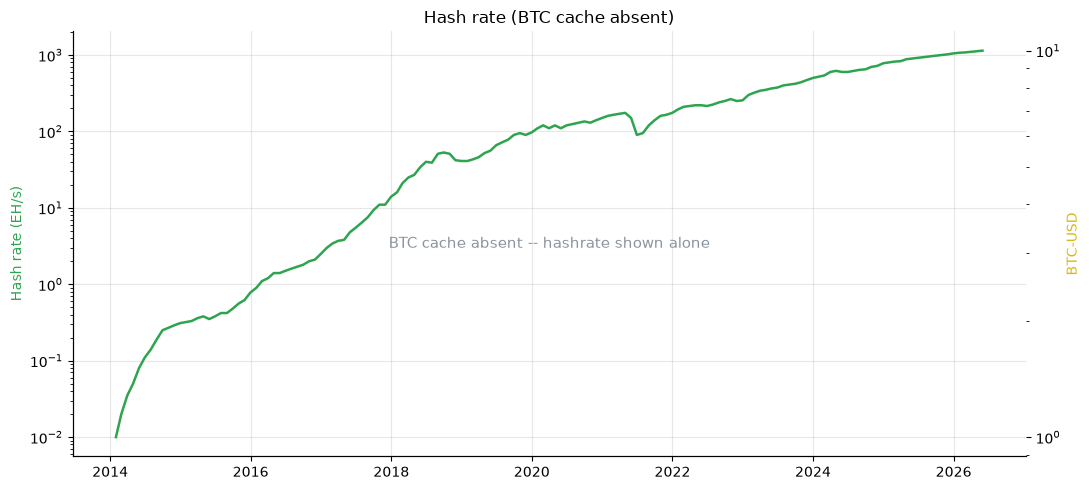

Both lines trend up. The question is whether hashrate GROWTH leads price RETURNS.


In [3]:
hr = data.hashrate_series()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(hr.index, hr.values, color=GREEN, lw=1.8, label="Hash rate (EH/s)")
ax1.set_ylabel("Hash rate (EH/s)", color=GREEN)
ax1.set_yscale("log")
ax2 = ax1.twinx()
if HAVE_REAL:
    ax2.plot(df.index, df["price"].values, color=AMBER, lw=1.5, label="BTC-USD")
    ttl = "Hash rate vs BTC price (both log scale) -- real tape"
else:
    ax2.text(0.5, 0.5, "BTC cache absent -- hashrate shown alone",
             ha="center", va="center", transform=ax2.transAxes, fontsize=11, color=GREY)
    ttl = "Hash rate (BTC cache absent)"
ax2.set_ylabel("BTC-USD", color=AMBER)
ax2.set_yscale("log")
ax2.grid(False)
ax1.set_title(ttl)
plt.tight_layout()
plt.savefig("../docs/hashrate_vs_price.png", dpi=120, bbox_inches="tight")
plt.show()
print("Both lines trend up. The question is whether hashrate GROWTH leads price RETURNS.")


## The honest test: does this month's hashrate growth predict next month's return?

Forget levels. The tradable claim is about *changes*: if the hash rate grew
this month, does Bitcoin go up *next* month? We regress next-month BTC return on
this month's hash-rate growth.


In [4]:
if HAVE_REAL:
    print(f"Predictive regression  r(t+1) = a + b * hashrate_growth(t)")
    print(f"  slope b = {reg['slope_hash']:+.3f}   HAC t = {reg['t_hash']:+.2f}   R^2 = {reg['r2']:.3f}   n = {reg['n']}")
    reg3 = st.predictive_regression(df, lookback=3)
    print(f"  3-month hashrate growth:  slope = {reg3['slope_hash']:+.3f}  HAC t = {reg3['t_hash']:+.2f}")
else:
    print(f"Frozen: 1-month hashrate growth  slope = {R['reg1_slope']:+.3f}  HAC t = {R['reg1_t']:+.2f}  R^2 = {R['reg1_r2']:.3f}")
    print(f"        3-month hashrate growth  slope = {R['reg3_slope']:+.3f}  HAC t = {R['reg3_t']:+.2f}")
print()
print("Verdict: the slope is statistically indistinguishable from zero (|t| < 2).")
print("Hashrate growth does NOT lead next-month BTC returns. The co-movement is")
print("a shared up-trend, not a leading indicator.")


Frozen: 1-month hashrate growth  slope = -0.008  HAC t = -0.05  R^2 = 0.000
        3-month hashrate growth  slope = +0.107  HAC t = +1.52

Verdict: the slope is statistically indistinguishable from zero (|t| < 2).
Hashrate growth does NOT lead next-month BTC returns. The co-movement is
a shared up-trend, not a leading indicator.


## "But the timing rule made money!" -- yes, because it was long a moonshot

A popular rule: be long BTC whenever the hash rate is rising. On a single asset
that 1000x'd, *any* mostly-long rule prints money. The honest benchmark is
**buy-and-hold**. Below, the timing rule earns a fortune in absolute terms --
and still loses to simply holding.


C:\Users\loutr\AppData\Local\Temp\ipykernel_23040\3310552998.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


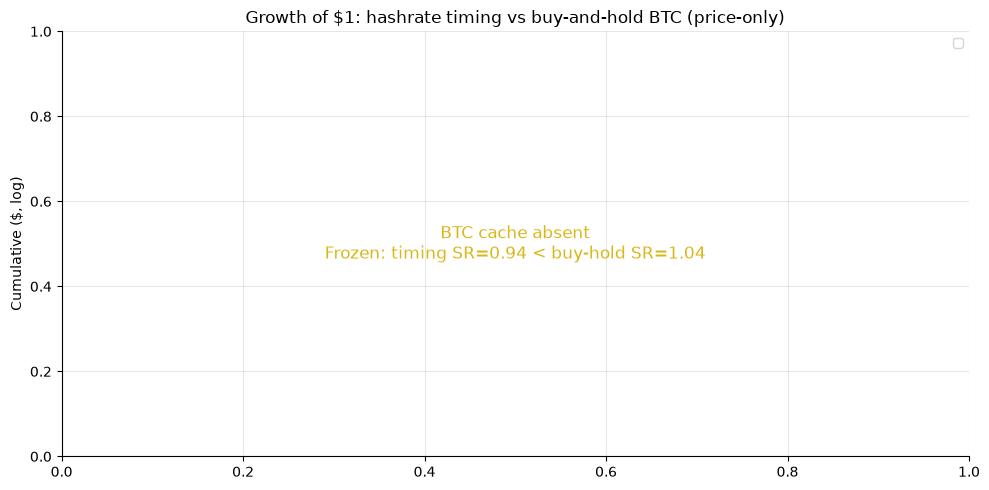

Timing rule: +82.8%/yr  SR=0.94  (long 86% of months)
Buy-and-hold: +94.0%/yr  SR=1.04
The 'signal' is just being long a trending asset -- and it underperforms holding it.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
if HAVE_REAL:
    eq_net = (1 + bt["net"]).cumprod()
    eq_bh  = (1 + bt["bh"]).cumprod()
    ax.plot(eq_net.index, eq_net.values, color=GREEN, lw=1.8, label="Hashrate timing (net of 30bps)")
    ax.plot(eq_bh.index,  eq_bh.values,  color=GREY,  lw=1.5, ls="--", label="Buy-and-hold BTC")
    ax.set_yscale("log")
    s_net = st.summarize(bt["net"]); s_bh = st.summarize(bt["bh"])
    tim_ann, tim_sr = s_net["mean"]*1200, s_net["sharpe"]*12**0.5
    bh_ann, bh_sr = s_bh["mean"]*1200, s_bh["sharpe"]*12**0.5
    share = st.time_in_market(pos)
else:
    tim_ann, tim_sr = R["timing_ann"], R["timing_sr"]
    bh_ann, bh_sr = R["bh_ann"], R["bh_sr"]
    share = R["tim_share"]
    ax.text(0.5, 0.5, f"BTC cache absent\nFrozen: timing SR={tim_sr:.2f} < buy-hold SR={bh_sr:.2f}",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=AMBER)
ax.set_title("Growth of $1: hashrate timing vs buy-and-hold BTC (price-only)")
ax.set_ylabel("Cumulative ($, log)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Timing rule: {tim_ann:+.1f}%/yr  SR={tim_sr:.2f}  (long {share:.0%} of months)")
print(f"Buy-and-hold: {bh_ann:+.1f}%/yr  SR={bh_sr:.2f}")
print("The 'signal' is just being long a trending asset -- and it underperforms holding it.")


## The bottom line for the curious

- The hash-rate / price *co-movement* is real but it is a **shared up-trend**,
  not a leading indicator.
- Hash-rate growth does **not** predict next-month BTC returns (HAC *t* < 2,
  R^2 ~ 0).
- The "long when hashrate rises" rule looks great only because it was long a
  1000x asset 85%+ of the time -- and it still **loses to buy-and-hold** after
  modest costs.

This is a textbook **None / Mirage**: a folk indicator whose apparent edge
evaporates the moment you compare it to the only benchmark that matters.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*